# 1. Basic prediction

Annotate cell types in a single-cell dataset with HECTOR, starting from the
raw output of a sequencing run.

HECTOR is a trained model, ready to use. Your cells are
encoded into a latent space and scored against learned prototypes for 1,407
cell types. 

A memory bank of 100,000 reference cells is loaded alongside the model. They
are there to give each of your cells a neighbourhood in the graph the encoder
attends over, so that an embedding reflects local context.

This tutorial begins where a real project begins: a **Cell Ranger output
folder**. The **quick start** below gets from that folder to annotated cells in
three lines.

The **full walkthrough** then does the job properly — quality control, and an
explanation of each decision — on a second dataset chosen because it comes
with **published cell type labels**. That lets the walkthrough finish by asking
the question the quick start cannot: *how accurate is any of this?*

## Getting the example data

We use a public 10x Genomics dataset — about 1,200 human peripheral blood
mononuclear cells (PBMCs), 3' v3 chemistry. The download is roughly 10 MB and
happens once; re-running this cell does nothing.

In [1]:
import pathlib
import shutil
import tarfile
import urllib.request

URL = ("https://cf.10xgenomics.com/samples/cell-exp/3.0.0/"
       "pbmc_1k_v3/pbmc_1k_v3_filtered_feature_bc_matrix.tar.gz")

if not pathlib.Path("filtered_feature_bc_matrix").exists():
    request = urllib.request.Request(URL, headers={"User-Agent": "hector-tutorial"})
    with urllib.request.urlopen(request) as response, \
            open("pbmc_1k_v3.tar.gz", "wb") as handle:
        shutil.copyfileobj(response, handle)
    with tarfile.open("pbmc_1k_v3.tar.gz") as archive:
        archive.extractall(".")

print(sorted(p.name for p in pathlib.Path("filtered_feature_bc_matrix").iterdir()))

['barcodes.tsv.gz', 'features.tsv.gz', 'matrix.mtx.gz']


## Quick start

Three lines from Cell Ranger output to annotated cells.

In [2]:
import hector

adata = hector.load_cellranger_data("filtered_feature_bc_matrix")
predictor = hector.HECTOR("human")                          # automatically downloads the model when first used
predictions = predictor.predict(adata, label_format="name")

  ✅ Found data in: filtered_feature_bc_matrix
  ✅ Loaded: 1222 cells x 33538 genes


<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded
  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully (MLX backend)! 🥳
   Supported cell types: 1407
  [INFO] Making predictions on 1222 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...
  Gene matching: 4978/5000 (99.6% of reference genes found)
  Step 2: Processing expression data...
  MLX adaptive batch size: 1222 (budget 18.8 GB, floor 5.7 GB)


  Encoding: 100%|██████████████████████████████| 1/1 [00:02<00:00,  2.09s/batch]


  Step 3: Predicting cell types...
  [INFO] Applying GRIT refinement...

  GRIT REFINEMENT
  Metric          Min      5%       25%      Median   75%      95%      Max     
  ---------------------------------------------------------------------------
  Entropy         2.58     2.70     2.83     2.99     3.21     3.42     3.88    
  ---------------------------------------------------------------------------

  [Auto-Thresholding]: Detected Threshold: 3.2348. Refining the lower 22.1% of the prediction distribution

  Step 4: Refining 270 cells using all 1,222 cells as neighbors ...


  kNN graph: 100%|██████████████████████████████| 1/1 [00:00<00:00, 41.94tile/s]

  ✅ Predictions complete!
  Step 5: Formatting results...
  ✅ Results formatted as DataFrame with shape (1222, 3)


The annotation is done — `predictions` holds a cell type for every cell.

Everything below is looking at it. `write_predictions()` copies the labels onto
the cells, `reduce_dimensions()` builds a 2-D map from HECTOR's own latent
space, and scanpy draws it. Allow about 15 seconds for the map.

  Rare-cell rollup summary: threshold=13 cells (min(1.0% of 1222, 20)), 47 type(s) bucketed as 'Rare Cells', 122 cell(s) affected
  Annotated adata.obs with 5 columns (prefix='hector_', 1222/1222 cells matched)
  Computing UMAP coordinates using the MLX (Metal GPU) engine ...


  UMAP: 100%|█████████████████████████████| 300/300 [00:00<00:00, 720.83epoch/s]


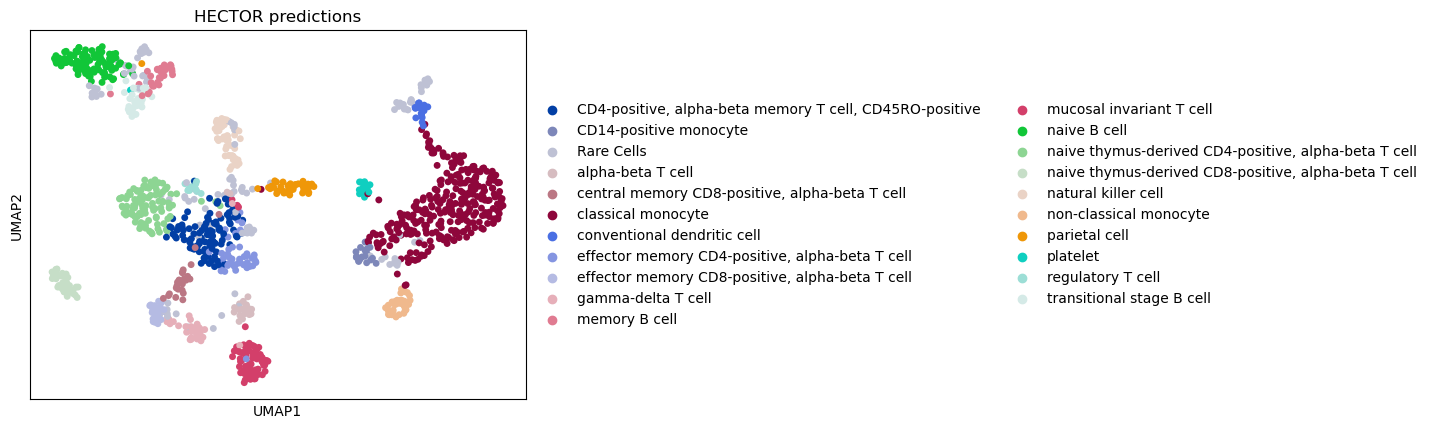

In [3]:
import scanpy as sc

predictor.write_predictions(adata, predictions)
predictor.reduce_dimensions(adata)
sc.pl.umap(adata, color="bucketed_prediction", title="HECTOR predictions")

That is a complete annotation. The rest of this tutorial explains what those
lines did, and what you should add before trusting the result on your own
data.

### A note on `load_cellranger_data()`

It finds the matrix for you. Point it at any of these and it will locate the
data underneath:

* the `filtered_feature_bc_matrix/` directory itself
* the `outs/` directory above it
* a `cellranger multi` run, where samples live under `per_sample_outs/`

Prefer the **filtered** matrix over the **raw** one. "Filtered" means Cell
Ranger has already separated real cells from empty droplets; the raw matrix
contains every barcode it saw, most of which are ambient noise.

## The full walkthrough

### Step 1 — Load a dataset with known answers

The walkthrough switches to a different dataset, for one reason: it carries
**cell type labels published by the people who generated it**. Nothing in
HECTOR was involved in producing them, so they can be used as an independent
check in Step 8.

It comes from a study that profiled peripheral blood from the **same two
donors on nine different sequencing platforms** — 10x Chromium v2 and v3,
Drop-seq, inDrops, Seq-Well, CEL-Seq2 and Smart-seq2. Holding the biology
fixed while varying the technology makes it a fair test of whether an
annotation method survives contact with data that was not generated the way
its training data was.

> Ding J, Adiconis X, Simmons SK, *et al.* Systematic comparison of
> single-cell and single-nucleus RNA-sequencing methods.
> *Nature Biotechnology* **38**, 737–746 (2020).
> [doi:10.1038/s41587-020-0465-8](https://doi.org/10.1038/s41587-020-0465-8)

It holds 31,021 cells with the full gene set retained. The download is about
70 MB and happens once; the whole walkthrough below runs in roughly two
minutes.

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc

DATA_URL = ("https://huggingface.co/datasets/polligator/HECTOR/"
            "resolve/main/pbmc_multiplatform.h5ad")

if not pathlib.Path("pbmc_multiplatform.h5ad").exists():
    request = urllib.request.Request(DATA_URL, headers={"User-Agent": "hector-tutorial"})
    with urllib.request.urlopen(request) as response, \
            open("pbmc_multiplatform.h5ad", "wb") as handle:
        shutil.copyfileobj(response, handle)

adata = sc.read_h5ad("pbmc_multiplatform.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 31021 × 33694
    obs: 'cell_type', 'donor', 'platform', 'count_type', 'n_genes_published', 'n_counts_published', 'percent_mito_published'
    var: 'gene_ids', 'gene_symbol'
    uns: 'dataset'
    obsm: 'X_tsne_harmony'


In [5]:
print(adata.obs.groupby(["platform"], observed=True).size().to_string())
print("\npublished labels:")
print(adata.obs["cell_type"].value_counts().to_string())

platform
10x Chromium v2      3362
10x Chromium v2 A    3222
10x Chromium v2 B    3222
10x Chromium v3      3222
CEL-Seq2              526
Drop-seq             6584
Seq-Well             3773
Smart-seq2            526
inDrops              6584

published labels:
cell_type
Cytotoxic T cell               9071
CD4+ T cell                    7391
CD14+ monocyte                 5550
B cell                         5020
Natural killer cell            1565
Megakaryocyte                   977
CD16+ monocyte                  804
Dendritic cell                  433
Plasmacytoid dendritic cell     164
Unassigned                       46


Three things to notice, because they are what HECTOR needs from *any* input.

**Gene identifiers.** HECTOR identifies genes by **Ensembl ID** (`ENSG...`),
kept here in `var["gene_ids"]`. Symbols get renamed between annotation
releases while IDs stay put, so IDs are what it matches on. Cell Ranger always
writes both, and this file carries both, so there is nothing to do — see the
closing section if your own data has symbols only.

**Raw counts.** `adata.X` holds unnormalized integers. Do not normalize,
log-transform, or scale before handing data to HECTOR — it does its own
processing internally, and pre-transformed input quietly degrades the
predictions.

**The published labels sit in `obs["cell_type"]`**, and `obs["platform"]`
records which technology produced each cell. Neither is used for prediction;
both are used to check it afterwards.

### Step 2 — Remove doublets

A doublet is two cells captured in one droplet and sequenced as though they
were one. They frequently look like a plausible intermediate cell type, so
they are worth removing before annotation rather than explaining away
afterwards.

**`detect_doublets()` only flags — it does not remove.** It writes two
columns to `adata.obs` and returns `None`:

| column | meaning |
| --- | --- |
| `doublet_score` | continuous score, higher means more doublet-like |
| `is_doublet` | boolean call at the expected rate |

Nothing else in HECTOR reads `is_doublet`, so if you do not subset, the
flagged cells stay in and get annotated like any other. Subsetting is your
job, and it is the step people most often miss.

**`batch_key` is the other thing people miss, and here it is not optional.**
`detect_doublets()` does not group your data by itself. Left alone it scores
every cell in one pass, and part of what makes a cell look like a doublet is
having an unusually large number of counts. Score nine platforms together and
that logic breaks: the deepest platform looks like a plate full of doublets
simply because it sequenced more deeply.

It is worth seeing how badly. Running this dataset both ways:

| platform | median counts | flagged, pooled | flagged, `batch_key="platform"` |
| --- | --- | --- | --- |
| Smart-seq2 | 328,458 | **91.3%** | 8.2% |
| CEL-Seq2 | 6,004 | **81.2%** | 8.6% |
| 10x Chromium v3 | 4,508 | 13.3% | 8.0% |
| Drop-seq | 1,427 | 5.7% | 8.0% |
| inDrops | 661 | **2.1%** | 8.0% |

Pooled, it would discard nine tenths of the Smart-seq2 cells and four fifths
of the CEL-Seq2 cells, and barely touch inDrops — deleting two platforms from
the experiment without a word of warning. Passing `batch_key` scores each
platform against its own distribution, and every one lands near the 8% asked
for.

The general rule: **if your object contains more than one sample, batch, or
chemistry, pass `batch_key`.** It costs nothing when the batches are alike and
rescues you when they are not.

In [6]:
hector.detect_doublets(adata, expected_doublet_rate=0.08, batch_key="platform")
print(f"flagged as doublets: {int(adata.obs['is_doublet'].sum())} of {adata.n_obs}")

adata = adata[~adata.obs["is_doublet"]].copy()              # <- the actual removal
print(f"kept: {adata.n_obs} cells")

flagged as doublets: 2487 of 31021
kept: 28534 cells


`expected_doublet_rate=0.08` means "expect about 8% doublets", which suits a
typical 10x run loaded at standard density. You should use a proper value based
on the kit manual — and note that a single rate is still an approximation here,
since these nine platforms load cells at different densities.

### Step 3 — Drop low-quality cells

`filter_cells()` removes cells with too few counts, too few detected genes,
or too much mitochondrial content (a dying-cell signature). The defaults are
written out here so you can see what you are getting:

In [7]:
counts_before = adata.obs.groupby("platform", observed=True).size()

hector.filter_cells(adata, min_counts=500, min_genes=200, max_mito_pct=20.0)
print(f"after QC: {adata.n_obs} cells")

after QC: 23464 cells


**Now look at *which* cells those thresholds removed.** This is the step where
a multi-platform dataset earns its keep:

In [8]:
survival = pd.DataFrame({
    "before": counts_before,
    "after": adata.obs.groupby("platform", observed=True).size(),
}).fillna(0).astype(int)
survival["kept_%"] = (100 * survival["after"] / survival["before"]).round(1)
survival["median_counts"] = (
    adata.obs.groupby("platform", observed=True)["n_counts_published"].median().round()
)
print(survival.sort_values("kept_%").to_string())

                   before  after  kept_%  median_counts
platform                                               
inDrops              6057   3312    54.7         1065.0
Seq-Well             3471   2436    70.2          936.0
10x Chromium v3      2964   2614    88.2         4570.0
10x Chromium v2 A    2964   2674    90.2         1918.0
10x Chromium v2 B    2964   2726    92.0         2396.0
CEL-Seq2              481    448    93.1         5980.0
Drop-seq             6057   5732    94.6         1396.0
10x Chromium v2      3093   3039    98.3         2558.0
Smart-seq2            483    483   100.0       319320.0


A single threshold applied to every platform does **not** treat every platform
equally. `min_counts=500` keeps almost all of the 10x and Smart-seq2 cells and
discards a large share of the inDrops and Seq-Well ones — not because those
cells are bad, but because those chemistries recover fewer transcripts per
cell by design. Their median cell has only a few hundred counts, so a fixed
floor cuts into the middle of their distribution instead of trimming its tail.

The practical lesson generalizes well beyond this dataset: **QC thresholds are
a property of the assay, not universal constants.** If you filter a mixed
collection of samples with one setting, you silently change the composition of
your experiment — here, you would be quietly deleting one technology's cells
while keeping another's. Choose thresholds by looking at the count
distribution of each batch, and expect to use different ones.

We keep the single permissive threshold here so the rest of the tutorial stays
simple. Just be aware of what it did.

### Step 4 — Load the model

Two public models are available:

| key | species |
| --- | --- |
| `"human"` | *Homo sapiens* |
| `"mouse"` | *Mus musculus* |


**Load the predictor once and reuse it.** Loading reads the whole reference
set into memory and takes several seconds, while annotating another dataset
afterwards is cheap by comparison. Never construct it inside a loop.

In [9]:
predictor = hector.HECTOR("human")
print("checkpoint version:", predictor.checkpoint_version)

  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded
  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully (MLX backend)! 🥳
   Supported cell types: 1407
checkpoint version: 3.0


### Step 5 — Predict

`label_format="name"` returns readable names such as `"classical monocyte"`.
The default is `"id"`, which returns Cell Ontology identifiers such as
`"CL:0000860"` — stable and machine-friendly, but hard to read. Use `"id"`
when you intend to match programmatically against an ontology.

`top_k=3` asks for the three best-matching cell types per cell instead of
only the winner, which is useful when you want to see what the runner-up was.

In [10]:
predictions = predictor.predict(adata, label_format="name", top_k=3)
predictions.head()

  [INFO] Making predictions on 23464 cells...
  Settings: top_k=3, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...
  Gene matching: 4954/5000 (99.1% of reference genes found)
  Step 2: Processing expression data...
  MLX adaptive batch size: 23464 (budget 18.3 GB, floor 5.7 GB)


  Encoding: 100%|██████████████████████████████| 1/1 [00:36<00:00, 36.72s/batch]


  Step 3: Predicting cell types...


  Predicting: 100%|████████████████████████████| 3/3 [00:03<00:00,  1.12s/batch]


  [INFO] Applying GRIT refinement...

  GRIT REFINEMENT
  Metric          Min      5%       25%      Median   75%      95%      Max     
  ---------------------------------------------------------------------------
  Entropy         2.50     2.79     3.04     3.25     3.38     3.53     4.20    
  ---------------------------------------------------------------------------

  [Auto-Thresholding]: Detected Threshold: 3.3156. Refining the lower 36.8% of the prediction distribution

  Step 4: Refining 8,627 cells using all 23,464 cells as neighbors ...


  kNN graph: 100%|██████████████████████████████| 9/9 [00:02<00:00,  3.07tile/s]


  ✅ Predictions complete!
  Step 5: Formatting results...
  ✅ Results formatted as DataFrame with shape (23464, 7)


,top_1_prediction,top_1_score,top_2_prediction,top_2_score,top_3_prediction,top_3_score,hector_cell_variance
cell_id,,,,,,,
pbmc1_Celseq2_1_ACAGAC,"CD4-positive, alpha-beta memory T cell, CD45RO...",0.043430,"CD4-positive, alpha-beta T cell",0.041334,"activated CD4-positive, alpha-beta T cell",0.035795,0.000395
pbmc1_Celseq2_1_ACAGGA,"effector CD4-positive, alpha-beta T cell",0.051907,"CD4-positive, alpha-beta memory T cell, CD45RO...",0.043580,effector T cell,0.042171,0.000757
pbmc1_Celseq2_1_ACGTTG,memory T cell,0.640364,"CD4-positive, alpha-beta memory T cell, CD45RO...",0.523775,"effector memory CD45RA-positive, alpha-beta T ...",0.492458,0.000673
pbmc1_Celseq2_1_AGACCA,"effector memory CD45RA-positive, alpha-beta T ...",0.555106,memory T cell,0.494404,"CD8-positive, alpha-beta memory T cell",0.485211,0.001351
pbmc1_Celseq2_1_CAACTC,"CD4-positive, alpha-beta T cell",0.040724,"CD4-positive, alpha-beta memory T cell, CD45RO...",0.039340,"CD4-positive, alpha-beta cytotoxic T cell",0.033152,0.000143


**`predict()` returns a DataFrame — the labels are not written into `adata`.**
That split is deliberate: it lets you inspect the result, compare several
settings, or throw a run away without having committed anything. The labels
appear only when you ask for them, in the next step.

It does leave three things on `adata`, all of which later steps reuse:
`obsm["X_hector"]` (the latent coordinates, which Step 7 turns into a UMAP),
`obs["hector_cell_variance"]`, and a couple of bookkeeping entries in `uns`.

One detail worth knowing, because it affects reproducibility. The encoder
embeds each cell using only that cell and the fixed memory bank, so an
embedding does not depend on which other cells you happened to load. The
**GRIT refinement** step that runs afterwards is different: it revisits the
least confident predictions using the *other cells in your file* as
neighbours. You will see it report how many cells it refined. So for that
subset, the label does depend on the company the cell keeps — which is the
point of the step, but it means predicting on a subset of your data will not
always reproduce the labels you got from the whole of it.

### Step 6 — Write the results into `adata.obs`

`write_predictions()` joins on cell barcodes and adds five columns:

| column | meaning |
| --- | --- |
| `hector_prediction` | the top-1 cell type label — always the raw label |
| `hector_prediction_confidence` | how the model's score distributed over its top choice |
| `hector_cell_variance` | per-cell uncertainty from the encoder |
| `bucketed_prediction` | rare types merged into one `"Rare Cells"` group |
| `is_bucketed` | whether this cell landed in that group |



The rollup columns exist because `rare_rollup=True` is the **default**. With
1,407 possible cell types a real dataset usually grows a long tail of types
holding one or two cells each, which makes a legend unreadable. The rollup
gives you a tidy column for figures while `hector_prediction` keeps every
original label. Set `rare_rollup=False` if you want only the raw column.


In [11]:
predictor.write_predictions(adata, predictions)

  Rare-cell rollup summary: threshold=20 cells (min(1.0% of 23464, 20)), 74 type(s) bucketed as 'Rare Cells', 325 cell(s) affected
  Annotated adata.obs with 5 columns (prefix='hector_', 23464/23464 cells matched)


In [12]:
adata.obs["hector_prediction"].value_counts().head(10)

hector_prediction
classical monocyte                                         2638
natural killer cell                                        1484
effector memory CD8-positive, alpha-beta T cell            1314
CD4-positive, alpha-beta memory T cell, CD45RO-positive    1207
gamma-delta T cell                                         1076
naive thymus-derived CD4-positive, alpha-beta T cell       1036
naive B cell                                                965
CD4-positive, alpha-beta cytotoxic T cell                   815
CD8-positive, alpha-beta T cell                             723
effector CD8-positive, alpha-beta T cell                    685
Name: count, dtype: int64

### Step 7 — Look at the result

`reduce_dimensions()` builds a 2-D UMAP from HECTOR's own latent space. Note
that this map comes from the model's own view of the cells, not from a separate
clustering — so the groups you see are the same information the labels came
from.

Before drawing it, there is a practical problem to solve. Look at the count
above: HECTOR answered with **around 150 distinct cell types** on this
dataset, because it names each cell as precisely as the evidence allows. That
precision is the point of the model, but 150 entries make an unreadable
legend.

`simplify_ontology_tree()` rolls those labels up along the cell ontology into
a smaller set of groups. It is not throwing information away — the original
labels stay in `hector_prediction` — it is choosing a coarser level of the same
hierarchy to look at.

Two arguments worth knowing. `algorithm="wang"` groups cell types by semantic
similarity in the ontology, with `similarity_threshold` setting how alike two
types must be before they merge — lower merges more aggressively.
`compute_transitions=False` skips the trajectory scoring the function can also
do; these are mature blood cells, so there are no meaningful transitions
between them to find, and the extra columns would only be noise. Tutorial 04
covers that side of the function on data where it applies.

In [13]:
predictor.reduce_dimensions(adata)

hector.simplify_ontology_tree(
    predictor, adata,
    algorithm="wang", similarity_threshold=0.7,
    compute_transitions=False, label_format="name",
)
print(f"{adata.obs['hector_prediction'].nunique()} predicted types "
      f"-> {adata.obs['simplified_prediction'].nunique()} groups")

  Computing UMAP coordinates using the MLX (Metal GPU) engine ...


  UMAP: 100%|█████████████████████████████| 300/300 [00:02<00:00, 107.40epoch/s]


154 predicted types -> 20 groups


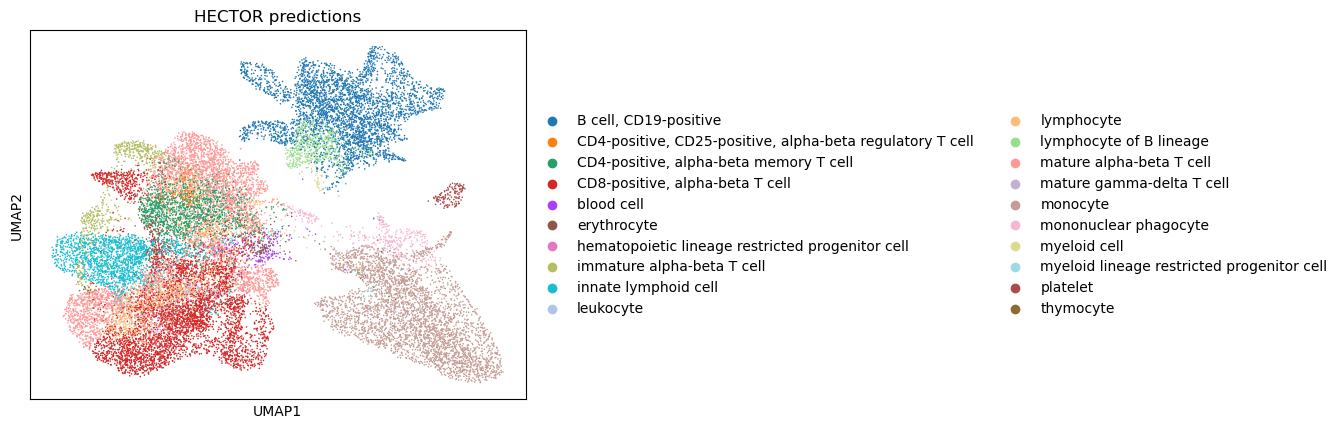

In [14]:
sc.pl.umap(adata, color="simplified_prediction", title="HECTOR predictions")

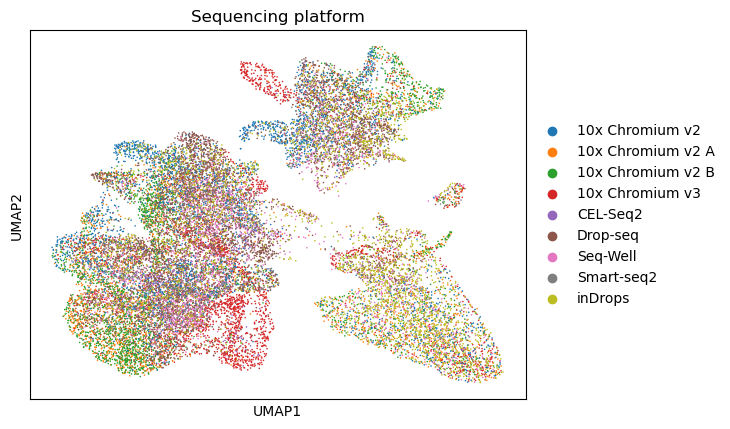

In [15]:
sc.pl.umap(adata, color="platform", title="Sequencing platform")

Compare the two maps. Cells group by **cell type**, and each group draws from
every platform at once — the nine technologies are mixed through the clusters
rather than forming nine separate islands.

That is worth a moment, because these platforms produce genuinely different
expression profiles for the same cell, and nothing here corrected for that.
HECTOR was never told which platform a cell came from; `obs["platform"]` is
used only for colouring. The mixing comes from the representation the encoder
learned during training.

### Step 8 — Check the labels against the published ones

Every dataset gives you predictions. This one lets you ask whether they are
right.

The obstacle is vocabulary, not accuracy. HECTOR answers in Cell Ontology
terms at whatever depth the evidence supports — `"CD8-positive, alpha-beta T
cell"`. The paper used nine categories of its own — `"Cytotoxic T cell"`.
Neither is wrong, but comparing them as text would score a more precise
correct answer as a mistake.

So translate HECTOR's answers into the paper's nine categories. The rules
below read only what each label *states* about itself — a label mentioning
CD8 is a cytotoxic T cell, one mentioning CD16 and monocyte is a CD16+
monocyte. They are written out rather than hidden in a helper file so you can
check them, and disagree.

Note this uses `hector_prediction`, the full-resolution answer, **not** the
simplified labels from Step 7. Simplification merges labels upward, which is
the wrong direction here: it would turn `"classical monocyte"` and
`"non-classical monocyte"` into a single `"monocyte"` that cannot be matched
to either of the paper's two monocyte categories. Simplification is for
reading a figure; comparison wants the detail.

In [16]:
def to_published_category(label):
    """Map a HECTOR label onto one of the paper's nine categories.

    Returns None when the paper has no equivalent category, which is a real
    outcome rather than a failure — see the note below.
    """
    text = str(label).lower()
    if "plasmacytoid dendritic" in text:
        return "Plasmacytoid dendritic cell"
    if "dendritic" in text:
        return "Dendritic cell"
    if "platelet" in text or "megakaryocyte" in text:
        return "Megakaryocyte"
    if "monocyte" in text and ("cd16-positive" in text or "non-classical" in text):
        return "CD16+ monocyte"
    if "monocyte" in text or "macrophage" in text:
        return "CD14+ monocyte"
    if "natural killer" in text:
        return "Natural killer cell"
    if "cd8" in text:
        return "Cytotoxic T cell"
    if "cd4" in text:
        return "CD4+ T cell"
    if "b cell" in text or "plasma" in text or "b lineage" in text:
        return "B cell"
    return None


scored = adata.obs[adata.obs["cell_type"] != "Unassigned"].copy()
scored["hector"] = scored["hector_prediction"].map(to_published_category)

unmatched = scored["hector"].isna()
print(f"no equivalent published category: {unmatched.sum()} cells "
      f"({100 * unmatched.mean():.1f}%)\n")
print(pd.crosstab(scored.loc[unmatched, "hector_prediction"],
                  scored.loc[unmatched, "cell_type"])
      .pipe(lambda d: d.loc[d.sum(1).sort_values(ascending=False).index[:6]])
      .loc[:, lambda d: d.sum() > 0].to_string())

no equivalent published category: 3199 cells (13.6%)

cell_type                  B cell  CD14+ monocyte  CD16+ monocyte  CD4+ T cell  Cytotoxic T cell  Dendritic cell  Megakaryocyte  Natural killer cell
hector_prediction                                                                                                                                   
gamma-delta T cell              3               2               1          133               863               0              0                   72
mucosal invariant T cell        0               0               0          115               199               0              0                    0
mature NK T cell                1               0               0           13               253               0              1                   31
mature gamma-delta T cell       0               0               0           14               197               0              0                   15
regulatory T cell               2               4   

Look at what those cells are before reading them as a shortfall. HECTOR is
naming **gamma-delta T cells, mucosal-associated invariant T cells, natural
killer T cells and regulatory T cells** — real populations that the paper's
nine categories simply do not contain, so the original authors filed them
under CD4 or CD8. Neither side is wrong; the vocabularies differ, and this is
the price of comparing against a fixed list.

Counting them as errors would be unfair, and dropping them silently would be
worse. Report them, then score the rest.

In [17]:
scored = scored[~unmatched].copy()
scored["agrees"] = scored["hector"] == scored["cell_type"]
print(f"agreement: {100 * scored['agrees'].mean():.1f}%  "
      f"({scored['agrees'].sum()} of {len(scored)} cells)")

agreement: 81.5%  (16508 of 20250 cells)


### The map you actually want to see

Both sides now speak the same vocabulary, so they can go side by side. Note
that **both panels use the same coordinates** — HECTOR's UMAP from Step 7 —
and only the colouring differs. That is deliberate. The dataset also ships the
paper's own embedding in `obsm["X_tsne_harmony"]`, and plotting the published
labels on that instead would look like a comparison but would not be one: you
could not tell a difference in labelling from a difference in layout.

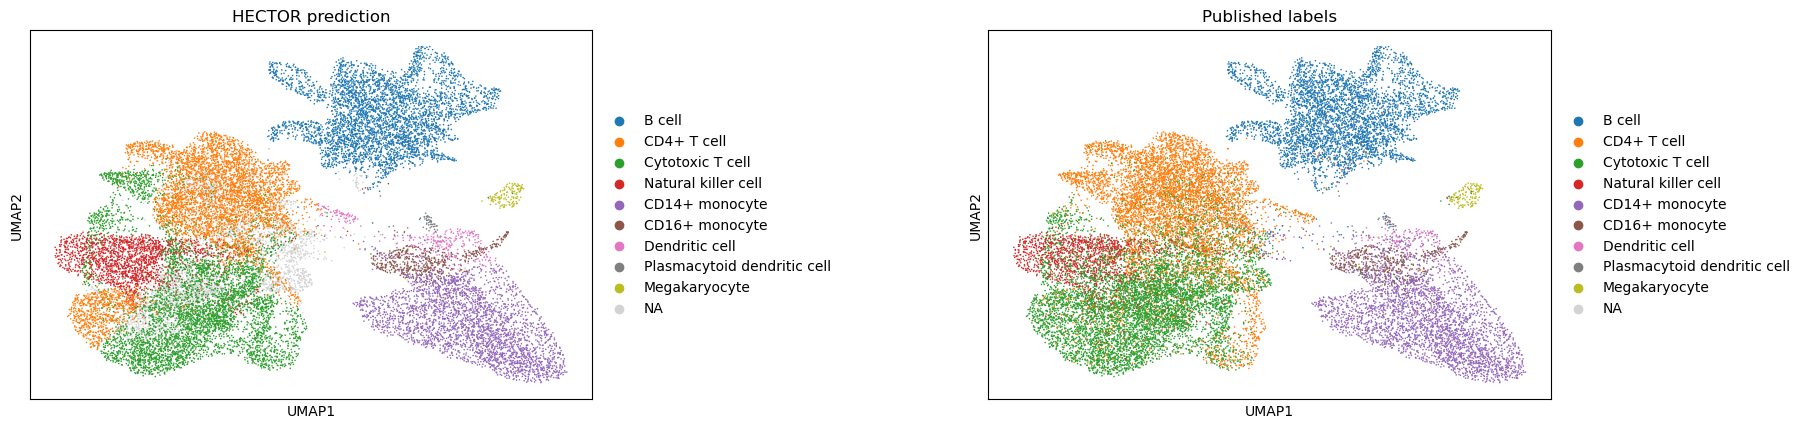

In [18]:
# Both columns must be categoricals over the *same* category list, in the same
# order. Without this scanpy colours each panel independently and the same cell
# type comes out a different colour on each side — which would make the figure
# actively misleading, since comparing colours is the entire point.
CATEGORIES = [
    "B cell", "CD4+ T cell", "Cytotoxic T cell", "Natural killer cell",
    "CD14+ monocyte", "CD16+ monocyte", "Dendritic cell",
    "Plasmacytoid dendritic cell", "Megakaryocyte",
]

adata.obs["hector_published_scale"] = pd.Categorical(
    adata.obs["hector_prediction"].map(to_published_category),
    categories=CATEGORIES)
adata.obs["published_labels"] = pd.Categorical(
    adata.obs["cell_type"].astype(str).where(adata.obs["cell_type"] != "Unassigned"),
    categories=CATEGORIES)

sc.pl.umap(adata, color=["hector_published_scale", "published_labels"], wspace=0.55,
           title=["HECTOR prediction", "Published labels"])

Read it as two pictures of the same map. Where the colours match, HECTOR and
the original authors agree; where a region changes colour between panels, they
do not. Grey in the left panel marks the cells with no equivalent published
category, and grey on the right is the handful the authors left
`"Unassigned"`.

Where does it disagree? A confusion table is more informative than a single
number:

In [19]:
pd.crosstab(scored["cell_type"], scored["hector"])

hector,B cell,CD14+ monocyte,CD16+ monocyte,CD4+ T cell,Cytotoxic T cell,Dendritic cell,Megakaryocyte,Natural killer cell,Plasmacytoid dendritic cell
cell_type,,,,,,,,,
B cell,4053,7,0,9,4,3,0,1,5
CD14+ monocyte,16,2932,98,25,10,132,5,6,7
CD16+ monocyte,1,50,422,1,0,4,0,0,0
CD4+ T cell,29,7,1,3955,1421,64,9,38,0
Cytotoxic T cell,9,8,0,1073,3713,7,10,566,0
Dendritic cell,3,17,0,0,0,103,0,0,9
Megakaryocyte,1,2,0,0,1,0,117,0,0
Natural killer cell,0,0,0,15,54,0,0,1175,0
Plasmacytoid dendritic cell,5,2,0,0,0,7,0,0,38


And, since the whole point of this dataset is that the technology varies while
the biology does not, the same score broken down by platform:

In [20]:
by_platform = scored.groupby("platform", observed=True)["agrees"].agg(
    cells="size", agreement=lambda x: round(100 * x.mean(), 1))
print(by_platform.sort_values("agreement", ascending=False).to_string())

                   cells  agreement
platform                           
10x Chromium v2     2652       92.2
inDrops             3023       84.9
10x Chromium v3     2497       81.7
Drop-seq            4560       81.4
10x Chromium v2 A   2385       79.1
Smart-seq2           401       79.1
10x Chromium v2 B   2429       77.4
Seq-Well            2053       72.3
CEL-Seq2             250       70.8


Read that table honestly: **the headline is not a single number.** Agreement
varies by platform, and a spread of that size is the most useful thing this
dataset has to tell you. Quote the range, not the average.

Three things to keep in view when interpreting any figure like this:

* **The published labels are not ground truth.** They came from the original
  authors' automated annotation pipeline, not manual expert curation. They are
  independent of HECTOR, which is what makes them a useful check, but
  disagreement does not automatically mean HECTOR is the one that is wrong.
* **CD4 versus CD8 is where the errors concentrate.** The confusion table
  shows the two T cell categories trading places far more than anything else.
  Everything coarser — B cells, monocytes, NK, platelets — is called
  accurately. That is worth knowing before you rely on a T cell subtype call.
* **The mapping rules are a judgement call.** Change them and the number
  changes. They are written out above rather than hidden away so you can check
  them against your own reading.

### Step 9 — Save

Write the annotated cells out. The file keeps the labels, the latent
coordinates and a record of what was computed, so loading it again and calling
`predict()` returns the same answers without repeating the work.

Each of the later tutorials fetches its own data, so none of them reads this
file — it is for your own use.

In [21]:
adata.write_h5ad("pbmc_multiplatform_annotated.h5ad")

## When an `.h5ad` has gene symbols only

The file used above already carried Ensembl IDs, but many public `.h5ad`
objects — and plenty of files sent by collaborators — carry gene **symbols**
only. That is the one thing that can be missing.

`map_gene_symbols()` translates symbols into Ensembl IDs, detecting the
species automatically:

```python
adata = sc.read_h5ad("collaborator_data.h5ad")
hector.map_gene_symbols(adata)      # no-op if Ensembl IDs are already there
```

It is safe to call unconditionally: if Ensembl IDs are present anywhere in
`adata.var` or its index, it does nothing. You only *need* it when they are
genuinely absent, in which case `filter_cells()` would otherwise stop with
`ValueError: Could not find Ensembl gene IDs`. Data straight from Cell Ranger
never has this problem, which is why the step does not appear above.

## What next

* **02 — tree visualization**: arrange these annotations on the cell ontology
  tree, so related types sit together and each population's size is visible.
* **03 — comparing groups on one tree**: draw that tree once per group —
  treated against control, one donor against another, early against late — on
  a single shared layout.
* **04 — fewer, broader labels**: the function Step 7 borrowed for its figure,
  covered properly — how it decides which types belong together, and what it
  writes besides the label.
* **05 — the genes behind a call**: which genes the model leaned on to reach
  these labels, ranked per cell type. It uses this dataset again, and reuses
  Step 8's mapping rules to group HECTOR's own answers before ranking.

One thing worth carrying forward: annotations can differ by a cell or two
between machines. HECTOR is deterministic on fixed hardware and settings, but
a cell sitting exactly between two reference types can tip either way under
ordinary floating-point rounding. Expect that when comparing runs across
machines; it is not a bug.